# EDA de reclamos CFPB

Este notebook documenta el análisis exploratorio paso a paso. Cada etapa se revisa antes de continuar.

## E0 — Verificar el archivo raw

**Pregunta:** ¿Estamos trabajando con el archivo correcto y cuál es su estructura física?

En este paso no transformamos datos ni cargamos el corpus completo en memoria. Solo revisamos el archivo, sus metadatos Parquet, su esquema y cinco registros protegidos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import display

### 1. Localizar el raw y su puntero DVC

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "data/raw/cfpb_reclamos_narrativa.parquet"
DVC_PATH = PROJECT_ROOT / "data/raw/cfpb_reclamos_narrativa.parquet.dvc"

assert RAW_PATH.exists(), f"No se encontró el raw: {RAW_PATH}"
assert DVC_PATH.exists(), f"No se encontró el puntero DVC: {DVC_PATH}"

dvc_lines = DVC_PATH.read_text(encoding="utf-8").splitlines()
dvc_md5 = next(line.split(":", 1)[1].strip() for line in dvc_lines if line.strip().startswith("- md5:"))

display(pd.DataFrame({
    "campo": ["archivo", "tamaño físico", "MD5 registrado por DVC"],
    "valor": [RAW_PATH.name, f"{RAW_PATH.stat().st_size / 1024**3:.2f} GiB", dvc_md5],
}))

,campo,valor
0,archivo,cfpb_reclamos_narrativa.parquet
1,tamaño físico,1.51 GiB
2,MD5 registrado por DVC,68f4560aca0967779f118e8225e72c26


### 2. Leer metadatos Parquet

Los metadatos permiten contar filas y columnas sin cargar todas las narrativas.

In [3]:
parquet = pq.ParquetFile(RAW_PATH)
metadata = parquet.metadata
logical_bytes = sum(metadata.row_group(i).total_byte_size for i in range(metadata.num_row_groups))

summary = pd.DataFrame({
    "medida": [
        "filas",
        "columnas",
        "grupos de filas",
        "tamaño físico",
        "tamaño lógico Parquet",
        "creado por",
    ],
    "valor": [
        f"{metadata.num_rows:,}",
        metadata.num_columns,
        metadata.num_row_groups,
        f"{RAW_PATH.stat().st_size / 1024**3:.2f} GiB",
        f"{logical_bytes / 1024**3:.2f} GiB",
        metadata.created_by,
    ],
})

assert metadata.num_rows == 3_837_184
assert metadata.num_columns == 16
display(summary)

,medida,valor
0,filas,"3,837,184"
1,columnas,16
2,grupos de filas,83
3,tamaño físico,1.51 GiB
4,tamaño lógico Parquet,3.73 GiB
5,creado por,parquet-cpp-arrow version 24.0.0


### 3. Revisar el esquema físico

In [4]:
schema = parquet.schema_arrow
schema_table = pd.DataFrame({
    "columna": [field.name for field in schema],
    "tipo parquet": [str(field.type) for field in schema],
    "permite nulos": [field.nullable for field in schema],
})
display(schema_table)

,columna,tipo parquet,permite nulos
0,Date received,large_string,True
1,Product,large_string,True
2,Sub-product,large_string,True
3,Issue,large_string,True
4,Sub-issue,large_string,True
5,Consumer complaint narrative,large_string,True
6,Company public response,large_string,True
7,Company,large_string,True
8,State,large_string,True
9,ZIP code,large_string,True


### 4. Verificar cinco registros sin publicar narrativas

La narrativa se reemplaza por su cantidad de caracteres para no guardar texto de consumidores en la salida del notebook.

In [5]:
sample = ds.dataset(RAW_PATH, format="parquet").head(5).to_pandas()
narrative_column = "Consumer complaint narrative"
sample[narrative_column] = sample[narrative_column].map(
    lambda text: f"<narrativa: {len(text):,} caracteres>" if isinstance(text, str) else "<sin narrativa>"
)
display(sample.T)

,0,1,2,3,4
Date received,2023-04-21,2023-07-13,2023-06-27,2024-05-06,2025-06-25
Product,Checking or savings account,"Money transfer, virtual currency, or money ser...",Mortgage,Debt collection,Student loan
Sub-product,Checking account,International money transfer,Other type of mortgage,Auto debt,Federal student loan servicing
Issue,Managing an account,Fraud or scam,Trouble during payment process,Took or threatened to take negative or legal a...,Dealing with your lender or servicer
Sub-issue,Deposits and withdrawals,NaN,NaN,Seized or attempted to seize your property,Trouble with how payments are being handled
Consumer complaint narrative,"<narrativa: 1,094 caracteres>","<narrativa: 1,392 caracteres>","<narrativa: 10,703 caracteres>",<narrativa: 779 caracteres>,"<narrativa: 1,206 caracteres>"
Company public response,Company has responded to the consumer and the ...,Company has responded to the consumer and the ...,Company has responded to the consumer and the ...,NaN,NaN
Company,U.S. BANCORP,"BANK OF AMERICA, NATIONAL ASSOCIATION",Specialized Loan Servicing Holdings LLC,TOYOTA MOTOR CREDIT CORPORATION,MOHELA
State,CA,GA,CA,CA,MA
ZIP code,91362,30032,94954,94112,02360


## Resultado de E0

- El archivo raw y su puntero DVC están disponibles.
- El archivo contiene **3,837,184 filas y 16 columnas**.
- La estructura puede inspeccionarse sin cargar el corpus completo en memoria.
- E0 no modifica el raw ni genera datos derivados.
- El siguiente paso, sujeto a aprobación, es **E1: revisar tipos, nulos, dominios y ejemplos de cada columna**.

## E1 — Revisar tipos, nulos y dominios

**Pregunta:** ¿Qué representa cada columna y qué tan completa está?

Primero contamos nulos desde los metadatos Parquet. Luego revisamos los valores más frecuentes de las columnas categóricas. La narrativa, las fechas y el identificador se estudiarán en sus pasos específicos.

### 1. Nulos por columna

In [6]:
null_rows = []
for column_index, field in enumerate(schema):
    statistics = [
        metadata.row_group(row_group).column(column_index).statistics
        for row_group in range(metadata.num_row_groups)
    ]
    assert all(stat is not None and stat.null_count is not None for stat in statistics)
    null_count = sum(stat.null_count for stat in statistics)
    null_rows.append({
        "columna": field.name,
        "nulos": null_count,
        "porcentaje": 100 * null_count / metadata.num_rows,
    })

null_table = pd.DataFrame(null_rows).sort_values("nulos", ascending=False, ignore_index=True)
null_display = null_table.copy()
null_display["nulos"] = null_display["nulos"].map("{:,}".format)
null_display["porcentaje"] = null_display["porcentaje"].map("{:.2f}%".format)
display(null_display)

,columna,nulos,porcentaje
0,Tags,"3,469,552",90.42%
1,Company public response,"1,795,421",46.79%
2,Sub-issue,"335,268",8.74%
3,Sub-product,"52,205",1.36%
4,State,"13,718",0.36%
5,ZIP code,290,0.01%
6,Company response to consumer,9,0.00%
7,Date received,0,0.00%
8,Company,0,0.00%
9,Consumer complaint narrative,0,0.00%


### 2. Tipo físico y significado esperado

El Parquet guarda las 16 columnas como texto. Eso no significa que deban conservar ese tipo después del EDA.

In [7]:
semantic_types = {
    "Date received": "fecha",
    "Product": "categoría",
    "Sub-product": "categoría",
    "Issue": "categoría",
    "Sub-issue": "categoría",
    "Consumer complaint narrative": "texto libre",
    "Company public response": "categoría",
    "Company": "categoría",
    "State": "categoría geográfica",
    "ZIP code": "identificador geográfico",
    "Tags": "categoría",
    "Submitted via": "categoría",
    "Date sent to company": "fecha",
    "Company response to consumer": "categoría / posible objetivo",
    "Timely response?": "binaria / posible objetivo",
    "Complaint ID": "identificador",
}

type_table = schema_table.copy()
type_table["significado esperado"] = type_table["columna"].map(semantic_types)
display(type_table)

,columna,tipo parquet,permite nulos,significado esperado
0,Date received,large_string,True,fecha
1,Product,large_string,True,categoría
2,Sub-product,large_string,True,categoría
3,Issue,large_string,True,categoría
4,Sub-issue,large_string,True,categoría
5,Consumer complaint narrative,large_string,True,texto libre
6,Company public response,large_string,True,categoría
7,Company,large_string,True,categoría
8,State,large_string,True,categoría geográfica
9,ZIP code,large_string,True,identificador geográfico


### 3. Dominios categóricos

Se cuentan valores distintos y se muestran los tres más frecuentes. Cada columna se lee por separado para mantener bajo el uso de memoria.

In [8]:
category_columns = [
    "Product", "Sub-product", "Issue", "Sub-issue",
    "Company public response", "Company", "State", "ZIP code",
    "Tags", "Submitted via", "Company response to consumer",
    "Timely response?",
]

domain_rows = []
for column in category_columns:
    values = pq.read_table(RAW_PATH, columns=[column]).column(0)
    counts = sorted(
        pc.value_counts(values).to_pylist(),
        key=lambda row: row["counts"],
        reverse=True,
    )
    non_null_counts = [row for row in counts if row["values"] is not None]
    top_three = " | ".join(
        f"{str(row['values'])[:45]} ({row['counts']:,})"
        for row in non_null_counts[:3]
    )
    domain_rows.append({
        "columna": column,
        "valores distintos": len(non_null_counts),
        "tres más frecuentes": top_three,
    })

domain_table = pd.DataFrame(domain_rows)
display(domain_table)

,columna,valores distintos,tres más frecuentes
0,Product,21,Credit reporting or other personal consumer r ...
1,Sub-product,85,"Credit reporting (2,457,199) | General-purpose..."
2,Issue,173,"Incorrect information on your report (1,205,00..."
3,Sub-issue,266,"Information belongs to someone else (697,613) ..."
4,Company public response,11,Company has responded to the consumer and the ...
5,Company,6831,"EQUIFAX, INC. (817,318) | TRANSUNION INTERMEDI..."
6,State,63,"TX (485,539) | FL (458,316) | CA (409,800)"
7,ZIP code,6938,"XXXXX (72,506) | 604XX (12,261) | 770XX (11,573)"
8,Tags,3,"Servicemember (240,176) | Older American (98,6..."
9,Submitted via,1,"Web (3,837,184)"


## Resultado de E1

- El archivo almacena las 16 columnas como texto, aunque fechas, categorías e identificadores tienen significados diferentes.
- Los mayores faltantes están en `Tags` (90.42%), `Company public response` (46.79%) y `Sub-issue` (8.74%). No los rellenaremos sin justificar primero qué significa su ausencia.
- `Submitted via` contiene únicamente `Web`; por tanto, no aporta variación en este dataset.
- Hay 21 productos, 173 issues y 6,831 empresas. Su frecuencia y concentración se estudiarán en E3.
- `Company response to consumer` y `Timely response?` ocurren después de ingresar el reclamo: pueden ser objetivos, pero no features de entrada.
- E1 describe el raw; todavía no cambia tipos ni rellena valores.
- El siguiente paso, sujeto a aprobación, es **E2: cobertura y volumen temporal**.

## E2 — Cobertura y volumen temporal

**Pregunta:** ¿Qué periodo cubren los reclamos y cómo cambia su volumen con el tiempo?

Solo se leen `Date received` y `Date sent to company`. El análisis temporal usa la fecha de recepción.

### 1. Convertir y validar las fechas

In [9]:
date_columns = ["Date received", "Date sent to company"]
date_text = pd.read_parquet(RAW_PATH, columns=date_columns, dtype_backend="pyarrow")
dates = date_text.apply(pd.to_datetime, format="%Y-%m-%d", errors="coerce")

date_quality = pd.DataFrame({
    "columna": date_columns,
    "mínimo": [dates[column].min().date() for column in date_columns],
    "máximo": [dates[column].max().date() for column in date_columns],
    "texto nulo": [date_text[column].isna().sum() for column in date_columns],
    "fecha inválida": [
        (dates[column].isna() & date_text[column].notna()).sum()
        for column in date_columns
    ],
})
del date_text
display(date_quality)

,columna,mínimo,máximo,texto nulo,fecha inválida
0,Date received,2015-03-19,2026-07-27,0,0
1,Date sent to company,2015-03-19,2026-08-13,0,0


### 2. Reclamos por año

El primer y el último año pueden estar incompletos dentro del archivo, por lo que no deben compararse directamente con años completos.

In [10]:
received = dates["Date received"]
annual_counts = received.dt.year.value_counts().sort_index()
annual_table = annual_counts.rename_axis("año").reset_index(name="reclamos")
annual_table["porcentaje"] = 100 * annual_table["reclamos"] / len(received)
annual_table["cobertura en el archivo"] = "año completo"
annual_table.loc[annual_table["año"] == received.min().year, "cobertura en el archivo"] = (
    f"desde {received.min().date()}"
)
annual_table.loc[annual_table["año"] == received.max().year, "cobertura en el archivo"] = (
    f"hasta {received.max().date()}"
)
annual_display = annual_table.copy()
annual_display["reclamos"] = annual_display["reclamos"].map("{:,}".format)
annual_display["porcentaje"] = annual_display["porcentaje"].map("{:.2f}%".format)
display(annual_display)

,año,reclamos,porcentaje,cobertura en el archivo
0,2015,"54,723",1.43%,desde 2015-03-19
1,2016,"77,766",2.03%,año completo
2,2017,"115,311",3.01%,año completo
3,2018,"118,393",3.09%,año completo
4,2019,"124,843",3.25%,año completo
5,2020,"174,297",4.54%,año completo
6,2021,"203,570",5.31%,año completo
7,2022,"337,273",8.79%,año completo
8,2023,"487,410",12.70%,año completo
9,2024,"814,384",21.22%,año completo


### 3. Reclamos por mes

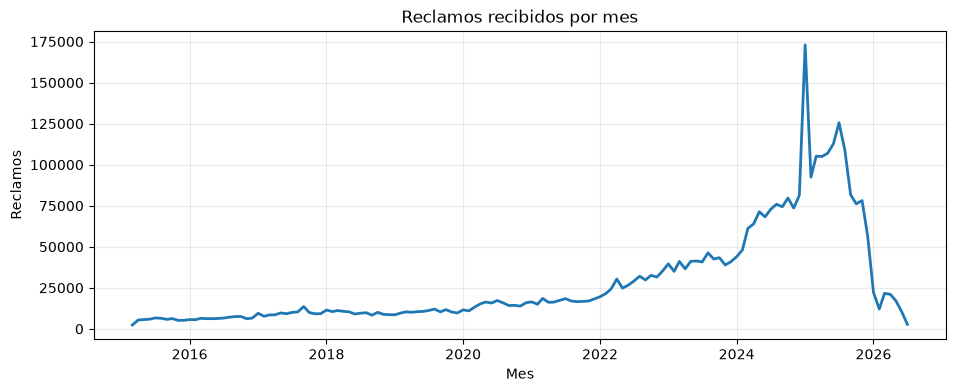

,mes,reclamos
0,2025-08,"108,868"
1,2025-09,"81,659"
2,2025-10,"76,162"
3,2025-11,"78,131"
4,2025-12,"56,510"
5,2026-01,"22,211"
6,2026-02,"12,100"
7,2026-03,"21,603"
8,2026-04,"21,024"
9,2026-05,"17,040"


In [11]:
monthly_counts = received.dt.to_period("M").value_counts().sort_index()
monthly_dates = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_dates, monthly_counts.values, linewidth=2)
ax.set(title="Reclamos recibidos por mes", xlabel="Mes", ylabel="Reclamos")
ax.grid(alpha=0.25)
plt.show()

recent_months = monthly_counts.tail(12).rename_axis("mes").reset_index(name="reclamos")
recent_months["mes"] = recent_months["mes"].astype(str)
recent_months["reclamos"] = recent_months["reclamos"].map("{:,}".format)
display(recent_months)

### 4. Tiempo hasta el envío a la empresa

Este intervalo mide cuándo CFPB envió el reclamo a la empresa. **No es tiempo de resolución ni permite medir el plazo bancario de 15 días hábiles.**

In [12]:
forwarding_days = (dates["Date sent to company"] - received).dt.days
forwarding_summary = pd.DataFrame({
    "medida": [
        "mismo día", "mediana", "percentil 95",
        "máximo", "intervalos negativos",
    ],
    "valor": [
        f"{(forwarding_days == 0).mean():.2%}",
        f"{forwarding_days.median():.0f} días",
        f"{forwarding_days.quantile(0.95):.0f} días",
        f"{forwarding_days.max():.0f} días",
        f"{(forwarding_days < 0).sum():,}",
    ],
})
display(forwarding_summary)

,medida,valor
0,mismo día,93.26%
1,mediana,0 días
2,percentil 95,2 días
3,máximo,1748 días
4,intervalos negativos,0


## Resultado de E2

- Las dos columnas se convierten a fecha sin valores inválidos ni faltantes.
- `Date received` cubre desde 2015-03-19 hasta 2026-07-27; 2015 y 2026 son años parciales dentro del archivo.
- El volumen crece fuertemente: 2025 concentra 1,222,056 reclamos (31.85% del corpus). Por eso una división aleatoria mezclaría periodos diferentes.
- La reducción observada en 2026 puede deberse a cobertura o retraso de publicación; no demuestra una caída real.
- CFPB envió 93.26% de los reclamos a la empresa el mismo día y 95% en dos días o menos, pero existe un máximo atípico de 1,748 días.
- `Date sent to company` no representa cierre ni resolución y no permite medir el plazo bancario de 15 días.
- La fecha principal para ordenar y dividir los reclamos será `Date received`; los cortes concretos se decidirán en E8.
- El siguiente paso, sujeto a aprobación, es **E3: productos, issues, empresas y canal de envío**.

## E3 — Productos, issues, empresas y canal

**Pregunta:** ¿Qué categorías dominan el dataset y cómo se relacionan producto e issue?

Este paso usa las etiquetas originales únicamente para entender el raw. Todavía no las agrupa ni canonicaliza.

In [13]:
del dates, received
category_columns = ["Product", "Issue", "Company", "Submitted via"]
categories = pd.read_parquet(RAW_PATH, columns=category_columns, dtype_backend="pyarrow")
categories.shape

(3837184, 4)

### 1. Productos

,producto,reclamos,porcentaje
0,Credit reporting or other personal consumer re...,"1,671,841",43.57%
1,"Credit reporting, credit repair services, or o...","807,499",21.04%
2,Debt collection,"441,051",11.49%
3,Checking or savings account,"186,789",4.87%
4,Mortgage,"146,301",3.81%
5,Credit card,"126,827",3.31%
6,"Money transfer, virtual currency, or money ser...","120,644",3.14%
7,Credit card or prepaid card,"108,683",2.83%
8,Student loan,"62,620",1.63%
9,Vehicle loan or lease,"53,005",1.38%


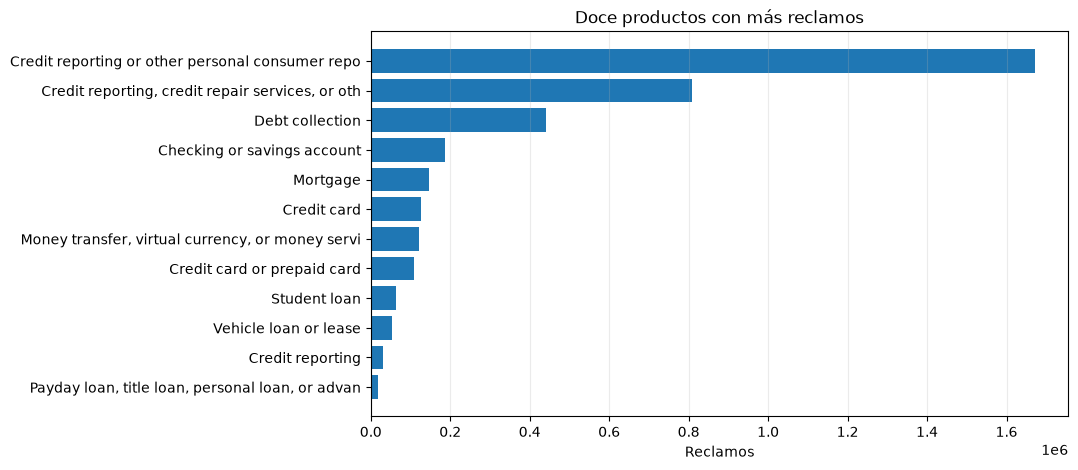

In [14]:
product_counts = categories["Product"].value_counts()
product_table = product_counts.rename_axis("producto").reset_index(name="reclamos")
product_table["porcentaje"] = 100 * product_table["reclamos"] / len(categories)
product_display = product_table.head(12).copy()
product_display["reclamos"] = product_display["reclamos"].map("{:,}".format)
product_display["porcentaje"] = product_display["porcentaje"].map("{:.2f}%".format)
display(product_display)

plot_data = product_table.head(12).sort_values("reclamos")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data["producto"].str.slice(0, 48), plot_data["reclamos"])
ax.set(title="Doce productos con más reclamos", xlabel="Reclamos", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 2. Issues

`Issue` describe el motivo asignado históricamente. En un reclamo nuevo puede ser un objetivo a predecir, pero no una feature de entrada.

,issue,reclamos,porcentaje
0,Incorrect information on your report,"1,205,002",31.40%
1,Improper use of your report,"664,039",17.31%
2,Problem with a company's investigation into an...,"349,237",9.10%
3,Problem with a credit reporting company's inve...,"250,448",6.53%
4,Attempts to collect debt not owed,"189,403",4.94%
5,Managing an account,"101,759",2.65%
6,Written notification about debt,"88,658",2.31%
7,Trouble during payment process,"56,347",1.47%
8,Other transaction problem,"54,759",1.43%
9,Problem with a purchase shown on your statement,"54,510",1.42%


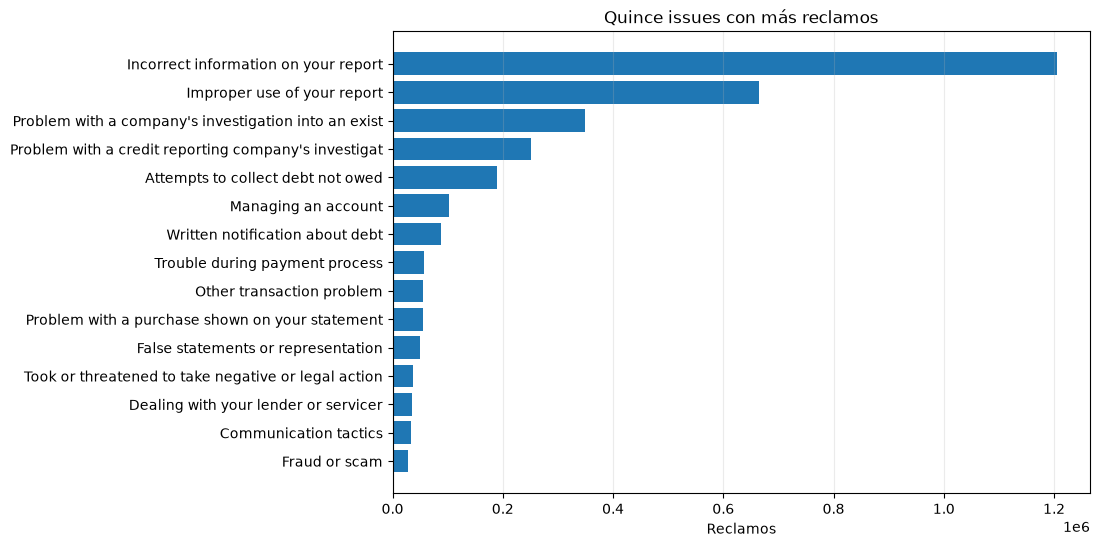

In [15]:
issue_counts = categories["Issue"].value_counts()
issue_table = issue_counts.rename_axis("issue").reset_index(name="reclamos")
issue_table["porcentaje"] = 100 * issue_table["reclamos"] / len(categories)
issue_display = issue_table.head(15).copy()
issue_display["reclamos"] = issue_display["reclamos"].map("{:,}".format)
issue_display["porcentaje"] = issue_display["porcentaje"].map("{:.2f}%".format)
display(issue_display)

plot_data = issue_table.head(15).sort_values("reclamos")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data["issue"].str.slice(0, 52), plot_data["reclamos"])
ax.set(title="Quince issues con más reclamos", xlabel="Reclamos", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 3. Relación producto–issue

Se muestra cuántos issues aparecen en cada producto y qué porcentaje ocupa su issue más frecuente.

In [16]:
product_issue = (
    categories.groupby(["Product", "Issue"], observed=True)
    .size()
    .rename("reclamos")
    .reset_index()
)
issues_per_product = product_issue.groupby("Product")["Issue"].size().rename("issues distintos")
top_issue = (
    product_issue.sort_values(["Product", "reclamos"], ascending=[True, False])
    .drop_duplicates("Product")
    .set_index("Product")
)
product_issue_summary = pd.concat([issues_per_product, top_issue[["Issue", "reclamos"]]], axis=1)
product_issue_summary["porcentaje del producto"] = (
    100 * product_issue_summary["reclamos"] / product_counts
)
product_issue_summary = (
    product_issue_summary.rename(columns={"Issue": "issue más frecuente"})
    .sort_values("reclamos", ascending=False)
    .reset_index(names="producto")
)
product_issue_display = product_issue_summary.copy()
product_issue_display["reclamos"] = product_issue_display["reclamos"].map("{:,}".format)
product_issue_display["porcentaje del producto"] = product_issue_display["porcentaje del producto"].map("{:.2f}%".format)
display(product_issue_display)

,producto,issues distintos,issue más frecuente,reclamos,porcentaje del producto
0,Credit reporting or other personal consumer re...,13,Incorrect information on your report,"830,986",49.70%
1,"Credit reporting, credit repair services, or o...",30,Incorrect information on your report,"353,734",43.81%
2,Debt collection,11,Attempts to collect debt not owed,"189,403",42.94%
3,Checking or savings account,13,Managing an account,"101,759",54.48%
4,Mortgage,16,Trouble during payment process,"56,345",38.51%
5,"Money transfer, virtual currency, or money ser...",17,Other transaction problem,"54,759",45.39%
6,Student loan,14,Dealing with your lender or servicer,"34,911",55.75%
7,Credit card,45,Problem with a purchase shown on your statement,"28,348",22.35%
8,Credit card or prepaid card,22,Problem with a purchase shown on your statement,"26,160",24.07%
9,Credit reporting,5,Incorrect information on credit report,"21,216",67.17%


### 4. Empresas

La concentración por empresa puede mejorar métricas dentro de CFPB, pero no necesariamente se transferirá a un banco donde la empresa sea siempre la misma.

In [17]:
company_counts = categories["Company"].value_counts()
company_table = company_counts.rename_axis("empresa").reset_index(name="reclamos")
company_table["porcentaje"] = 100 * company_table["reclamos"] / len(categories)
company_table["porcentaje acumulado"] = company_table["porcentaje"].cumsum()
company_display = company_table.head(15).copy()
company_display["reclamos"] = company_display["reclamos"].map("{:,}".format)
company_display["porcentaje"] = company_display["porcentaje"].map("{:.2f}%".format)
company_display["porcentaje acumulado"] = company_display["porcentaje acumulado"].map("{:.2f}%".format)
display(company_display)

concentration = pd.DataFrame({
    "grupo": ["empresa principal", "10 principales", "100 principales"],
    "porcentaje de reclamos": [
        company_counts.iloc[:1].sum() / len(categories),
        company_counts.iloc[:10].sum() / len(categories),
        company_counts.iloc[:100].sum() / len(categories),
    ],
})
concentration["porcentaje de reclamos"] = concentration["porcentaje de reclamos"].map("{:.2%}".format)
display(concentration)

,empresa,reclamos,porcentaje,porcentaje acumulado
0,"EQUIFAX, INC.","817,318",21.30%,21.30%
1,"TRANSUNION INTERMEDIATE HOLDINGS, INC.","775,030",20.20%,41.50%
2,Experian Information Solutions Inc.,"737,722",19.23%,60.72%
3,CAPITAL ONE FINANCIAL CORPORATION,"70,826",1.85%,62.57%
4,JPMORGAN CHASE & CO.,"65,005",1.69%,64.26%
5,WELLS FARGO & COMPANY,"60,724",1.58%,65.85%
6,"BANK OF AMERICA, NATIONAL ASSOCIATION","58,743",1.53%,67.38%
7,"CITIBANK, N.A.","55,558",1.45%,68.82%
8,"Block, Inc.","48,634",1.27%,70.09%
9,SYNCHRONY FINANCIAL,"35,130",0.92%,71.01%


,grupo,porcentaje de reclamos
0,empresa principal,21.30%
1,10 principales,71.01%
2,100 principales,88.95%


### 5. Canal disponible

In [18]:
channel_table = categories["Submitted via"].value_counts().rename_axis("canal").reset_index(name="reclamos")
channel_table["porcentaje"] = 100 * channel_table["reclamos"] / len(categories)
display(channel_table)

,canal,reclamos,porcentaje
0,Web,3837184,100.0


## Resultado de E3

- Las tres etiquetas relacionadas con credit reporting concentran aproximadamente 65.43% de los reclamos. Además, nombres como `Credit card` y `Credit card or prepaid card` evidencian cambios históricos de taxonomía.
- Los dos issues principales reúnen 48.71% del corpus. Producto e issue están fuertemente desbalanceados; la exactitud global sería una métrica insuficiente.
- La relación producto–issue debe conservarse porque el motivo dominante cambia según el producto.
- `Fraud or scam` aparece en 28,291 reclamos (0.74%), pero es una categoría declarada y no fraude confirmado.
- Las tres empresas principales concentran 60.72% de los reclamos y las diez primeras 71.01%. `Company` debe evaluarse con y sin esa feature antes de hablar de transferencia.
- `Issue` puede ser un objetivo de modelado, pero no una feature de entrada para un reclamo nuevo.
- `Submitted via` es `Web` en 100% del archivo y no debe convertirse en feature.
- E3 aporta evidencia para canonicalizar categorías en E9, pero todavía conserva todas las etiquetas originales.
- El siguiente paso, sujeto a aprobación, es **E4: respuestas de la empresa y posibles objetivos**.

## E4 — Respuestas de la empresa y posibles objetivos

**Pregunta:** ¿Qué resultados históricos podemos convertir en etiquetas sin confundirlos con información disponible al ingresar un reclamo?

Estas columnas describen lo ocurrido después del reclamo. Pueden servir como objetivos, pero nunca como features de entrada.

In [19]:
del categories
response_columns = ["Company response to consumer", "Timely response?"]
responses = pd.read_parquet(RAW_PATH, columns=response_columns, dtype_backend="pyarrow")
responses.shape

(3837184, 2)

### 1. Respuestas registradas

,respuesta,reclamos,porcentaje
0,Closed with explanation,"2,548,866",66.425%
1,Closed with non-monetary relief,"1,175,215",30.627%
2,Closed with monetary relief,"98,150",2.558%
3,Untimely response,"11,092",0.289%
4,Closed,"3,741",0.097%
5,In progress,111,0.003%
6,<NA>,9,0.000%


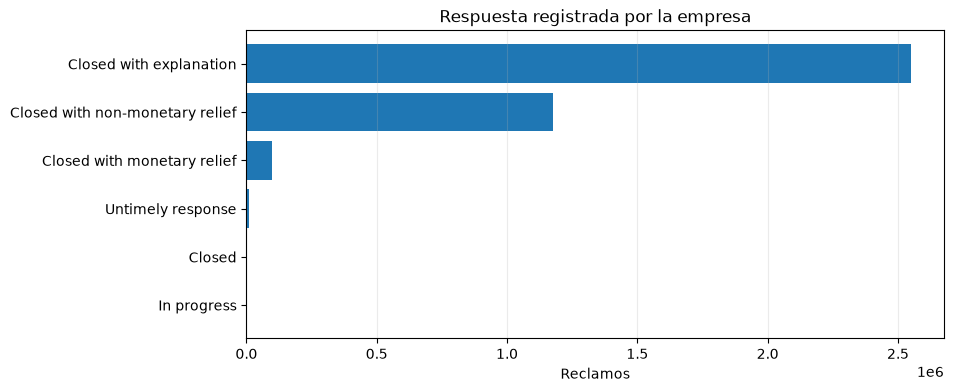

In [20]:
response_counts = responses["Company response to consumer"].value_counts(dropna=False)
response_table = response_counts.rename_axis("respuesta").reset_index(name="reclamos")
response_table["porcentaje"] = 100 * response_table["reclamos"] / len(responses)
response_display = response_table.copy()
response_display["reclamos"] = response_display["reclamos"].map("{:,}".format)
response_display["porcentaje"] = response_display["porcentaje"].map("{:.3f}%".format)
display(response_display)

plot_data = response_table.dropna(subset=["respuesta"]).sort_values("reclamos")
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_data["respuesta"], plot_data["reclamos"])
ax.set(title="Respuesta registrada por la empresa", xlabel="Reclamos", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 2. Reglas candidatas para T2, T3 y T4

Para T2 y T3 solo consideramos resultados cuyo significado es explícito:

| Respuesta histórica | T2: algún relief | T3: relief monetario |
|---|---:|---:|
| `Closed with monetary relief` | Sí | Sí |
| `Closed with non-monetary relief` | Sí | No |
| `Closed with explanation` | No | No |
| Cualquier otra respuesta o nulo | Desconocido | Desconocido |

`Closed with explanation` sí participa: es la clase negativa explícita. No significa una mala respuesta; significa que no se registró relief monetario o no monetario.

In [21]:
response = responses["Company response to consumer"]
explicit_responses = [
    "Closed with monetary relief",
    "Closed with non-monetary relief",
    "Closed with explanation",
]
eligible = response.isin(explicit_responses)

targets = pd.DataFrame(index=responses.index)
targets["T2_relief"] = pd.Series(pd.NA, index=responses.index, dtype="boolean")
targets.loc[eligible, "T2_relief"] = response[eligible].isin(explicit_responses[:2]).to_numpy()
targets["T3_monetary_relief"] = pd.Series(pd.NA, index=responses.index, dtype="boolean")
targets.loc[eligible, "T3_monetary_relief"] = response[eligible].eq(explicit_responses[0]).to_numpy()
targets["T4_untimely"] = responses["Timely response?"].eq("No").astype("boolean")

assert targets.loc[targets["T3_monetary_relief"].eq(True), "T2_relief"].all()
targets.head()

,T2_relief,T3_monetary_relief,T4_untimely
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,True


### 3. Balance de los objetivos candidatos

,objetivo,positivos,negativos,desconocidos,tasa positiva
0,T2 — algún relief,"1,273,365","2,548,866","14,953",33.315%
1,T3 — relief monetario,"98,150","3,724,081","14,953",2.568%
2,T4 — respuesta no oportuna CFPB,"42,615","3,794,569",0,1.111%


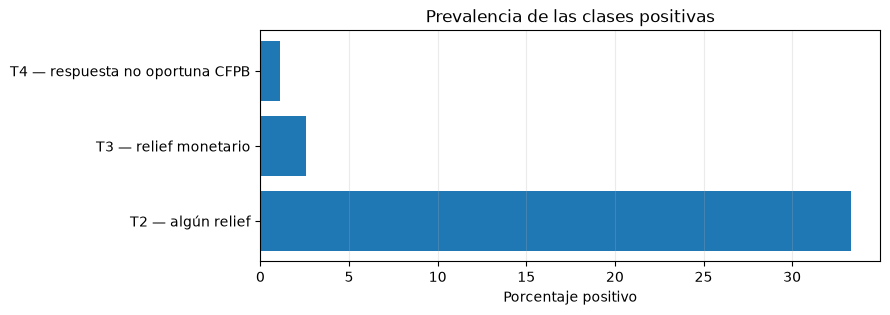

Timely response?,No,Yes,All
Company response to consumer,,,
<nulo>,0,9,9
Closed,536,3205,3741
Closed with explanation,28271,2520595,2548866
Closed with monetary relief,1180,96970,98150
Closed with non-monetary relief,1536,1173679,1175215
In progress,0,111,111
Untimely response,11092,0,11092
All,42615,3794569,3837184


In [22]:
target_names = {
    "T2_relief": "T2 — algún relief",
    "T3_monetary_relief": "T3 — relief monetario",
    "T4_untimely": "T4 — respuesta no oportuna CFPB",
}
target_rows = []
for column, name in target_names.items():
    values = targets[column]
    known = values.notna()
    positives = values.eq(True).sum()
    negatives = values.eq(False).sum()
    target_rows.append({
        "objetivo": name,
        "positivos": positives,
        "negativos": negatives,
        "desconocidos": (~known).sum(),
        "tasa positiva": 100 * positives / known.sum(),
    })

target_table = pd.DataFrame(target_rows)
target_display = target_table.copy()
for column in ["positivos", "negativos", "desconocidos"]:
    target_display[column] = target_display[column].map("{:,}".format)
target_display["tasa positiva"] = target_display["tasa positiva"].map("{:.3f}%".format)
display(target_display)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(target_table["objetivo"], target_table["tasa positiva"])
ax.set(title="Prevalencia de las clases positivas", xlabel="Porcentaje positivo", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

timeliness_by_response = pd.crosstab(
    responses["Company response to consumer"].fillna("<nulo>"),
    responses["Timely response?"],
    margins=True,
)
display(timeliness_by_response)

### 4. Disponibilidad y fuga de información

| Campo | Uso permitido | Motivo |
|---|---|---|
| `Issue` | Objetivo T1 | Se asignó históricamente; no se asume conocido al ingreso |
| `Company response to consumer` | Construir T2 y T3 | Ocurre después de la respuesta |
| `Timely response?` | Construir T4 | Ocurre después de la respuesta |
| `Company public response` | No usar como feature | Texto posterior que puede revelar el resultado |
| `Date sent to company` | Análisis del proceso CFPB | No es fecha de cierre y puede no existir al ingreso |

## Resultado de E4

- T2 y T3 usan 3,822,231 respuestas explícitas; 14,953 respuestas ambiguas permanecen desconocidas en vez de convertirse artificialmente en `False`.
- T2 tiene 1,273,365 positivos (33.315%) y T3 tiene 98,150 (2.568%). T3 es subconjunto de T2.
- `Closed with explanation` representa 66.425% del corpus y es el negativo explícito de T2 y T3.
- T4 tiene 42,615 positivos (1.111%). Debe derivarse de `Timely response? = No`, no de la categoría `Untimely response`, que solo aparece 11,092 veces.
- T4 mide la respuesta oportuna reportada por CFPB; no mide resolución ni el plazo bancario de 15 días.
- Ninguna columna usada para construir T1–T4 puede entrar como feature del mismo objetivo.
- El siguiente paso, sujeto a aprobación, es **E5: calidad y longitud de las narrativas**.

## E5 — Calidad y longitud de las narrativas

**Pregunta:** ¿Las narrativas contienen texto utilizable y qué longitudes deberá soportar la representación?

No se publican narrativas. Solo se calculan medidas agregadas sobre todo el corpus.

In [23]:
import gc
import re

del responses, response, targets, values, eligible
gc.collect()

narrative_column = "Consumer complaint narrative"
narratives = pd.read_parquet(
    RAW_PATH, columns=[narrative_column], dtype_backend="pyarrow"
)[narrative_column]
narratives.shape

(3837184,)

### 1. Vacíos y longitud

In [24]:
empty_narratives = narratives.str.fullmatch(r"\s*").fillna(False).sum()
character_count = narratives.str.len()
word_count = narratives.str.count(r"\S+")

quantiles = [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
length_table = pd.DataFrame({
    "percentil": [f"{value:.0%}" for value in quantiles],
    "caracteres": character_count.quantile(quantiles).round().astype("int64").to_numpy(),
    "palabras aproximadas": word_count.quantile(quantiles).round().astype("int64").to_numpy(),
})
display(length_table)

,percentil,caracteres,palabras aproximadas
0,0%,4,1
1,1%,63,11
2,5%,127,22
3,25%,346,61
4,50%,669,117
5,75%,1221,214
6,95%,3002,518
7,99%,5873,1021
8,100%,35984,6469


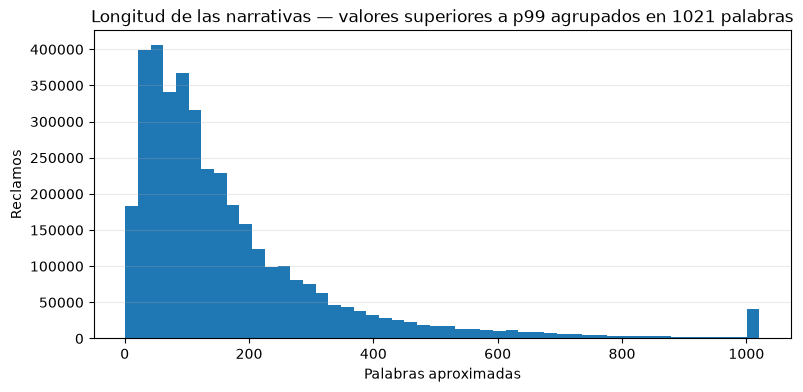

In [25]:
word_limit = int(word_count.quantile(0.99))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(word_count.clip(upper=word_limit).to_numpy(), bins=50)
ax.set(
    title=f"Longitud de las narrativas — valores superiores a p99 agrupados en {word_limit} palabras",
    xlabel="Palabras aproximadas",
    ylabel="Reclamos",
)
ax.grid(axis="y", alpha=0.25)
plt.show()

### 2. Señales simples de calidad

Más de 400 palabras es solo una señal conservadora de posible truncamiento en encoders con límite de tokens. Palabras y tokens no son equivalentes.

In [26]:
quality_metrics = pd.DataFrame({
    "señal": [
        "narrativa nula",
        "vacía después de quitar espacios",
        "menos de 20 palabras",
        "más de 400 palabras",
        "contiene XXXX de anonimización",
        "contiene salto de línea",
    ],
    "reclamos": [
        narratives.isna().sum(),
        empty_narratives,
        (word_count < 20).sum(),
        (word_count > 400).sum(),
        narratives.str.contains("XXXX", regex=False, na=False).sum(),
        narratives.str.contains("\n", regex=False, na=False).sum(),
    ],
})
quality_metrics["porcentaje"] = 100 * quality_metrics["reclamos"] / len(narratives)
quality_display = quality_metrics.copy()
quality_display["reclamos"] = quality_display["reclamos"].map("{:,}".format)
quality_display["porcentaje"] = quality_display["porcentaje"].map("{:.2f}%".format)
display(quality_display)

,señal,reclamos,porcentaje
0,narrativa nula,0,0.00%
1,vacía después de quitar espacios,0,0.00%
2,menos de 20 palabras,"157,017",4.09%
3,más de 400 palabras,"323,582",8.43%
4,contiene XXXX de anonimización,"2,593,664",67.59%
5,contiene salto de línea,"1,564,092",40.76%


### 3. Idioma aparente en una muestra

La siguiente regla compara palabras funcionales inglesas y españolas en una muestra determinística de 20,000 narrativas. Es un diagnóstico aproximado, no una etiqueta confiable ni una feature.

In [27]:
english_markers = {"the", "and", "to", "of", "is", "was", "that", "with", "for", "my", "on", "account", "company"}
spanish_markers = {"el", "la", "los", "las", "de", "que", "y", "en", "mi", "con", "para", "cuenta", "empresa"}

def language_hint(text):
    words = re.findall(r"[a-záéíóúüñ]+", text.lower())
    english_score = sum(word in english_markers for word in words)
    spanish_score = sum(word in spanish_markers for word in words)
    if english_score >= 5 and english_score >= 2 * spanish_score:
        return "inglés aparente"
    if spanish_score >= 5 and spanish_score >= 2 * english_score:
        return "español aparente"
    return "indeterminado"

sample_size = 20_000
step = max(len(narratives) // sample_size, 1)
language_sample = narratives.iloc[::step].head(sample_size)
language_counts = language_sample.map(language_hint).value_counts()
language_table = language_counts.rename_axis("resultado").reset_index(name="narrativas")
language_table["porcentaje"] = 100 * language_table["narrativas"] / len(language_sample)
language_table["porcentaje"] = language_table["porcentaje"].map("{:.2f}%".format)
display(language_table)

,resultado,narrativas,porcentaje
0,inglés aparente,18776,93.88%
1,indeterminado,1224,6.12%


## Resultado de E5

- No existen narrativas nulas o vacías después de retirar espacios.
- La narrativa mediana tiene 117 palabras; el percentil 95 tiene 518, el percentil 99 tiene 1,021 y el máximo 6,469.
- 323,582 narrativas (8.43%) superan 400 palabras. Los encoders con límite de tokens necesitarán una política explícita de truncamiento o fragmentación.
- 157,017 narrativas (4.09%) tienen menos de 20 palabras y pueden aportar poco contexto, aunque no se eliminarán automáticamente.
- `XXXX` aparece en 2,593,664 narrativas (67.59%); es anonimización y deberá normalizarse consistentemente, no interpretarse como una palabra.
- En la muestra de 20,000 textos, 93.88% parece inglés y 6.12% queda indeterminado. Ningún texto superó el umbral de español, pero la heurística no demuestra que el corpus sea exclusivamente inglés.
- El siguiente paso, sujeto a aprobación, es **E6: IDs duplicados y narrativas repetidas**.